In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, find_peaks


file_path = "../../data/raw/WESAD/S2/S2_respiban.txt"

data = pd.read_csv(
    file_path,
    sep="\t",        # change to " " if space-separated
    header=None,
    comment="#",     # ignores metadata lines starting with #
)

print(data.head())
print(data.shape)

   0   1      2      3      4      5      6      7      8      9   10
0   0   0  31053  14694  32651  29553  37415  32324  31659  31364 NaN
1   1   0  30861  14680  32983  29556  37417  32333  31663  31379 NaN
2   2   0  30644  14684  32823  29561  37409  32340  31655  31367 NaN
3   3   0  30374  14701  32569  29553  37405  32341  31671  31076 NaN
4   4   0  30103  14684  32794  29561  37409  32342  31681  31365 NaN
(4442067, 11)


      Metric           Raw      Filtered   % Change
0       Mean  1.180804e-12 -2.029719e-07 -20.297282
1        Std  8.690489e+02  8.690004e+02  -0.005578
2      Noise  1.926765e+01  9.368016e+00 -51.379552
3      Drift  2.904592e+02  2.909478e+02   0.168237
4   Outliers  0.000000e+00  0.000000e+00   0.000000
5  Slope Var  1.926765e+01  9.368016e+00 -51.379552


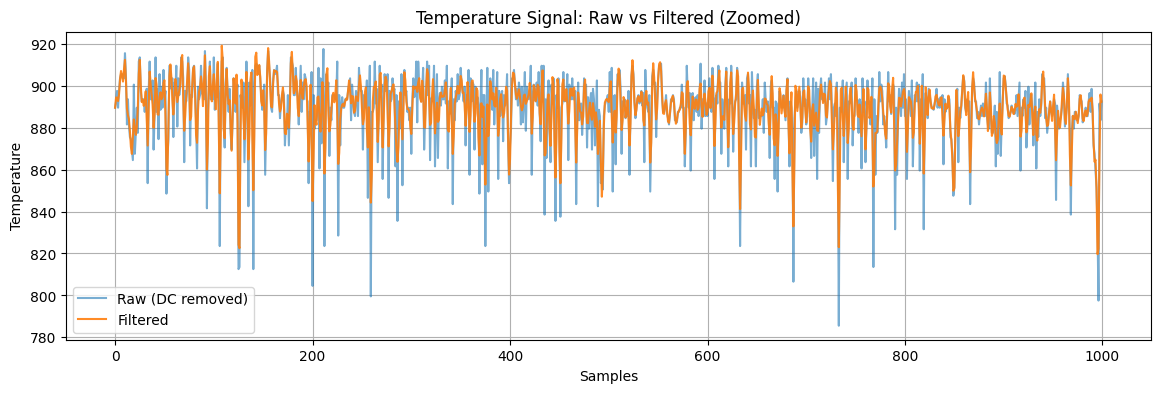

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
 

# =========================================================
# 2. EXTRACT TEMPERATURE (INDEX 5)
# =========================================================
temp_raw = data.iloc[:, 5].values.astype(float)

# =========================================================
# 3. DC OFFSET REMOVAL (OPTIONAL BUT GOOD)
# =========================================================
temp_dc = temp_raw - np.mean(temp_raw)

# =========================================================
# 4. LOW-PASS FILTER (TEMPERATURE = SLOW SIGNAL)
# =========================================================
def lowpass(signal, fs=1, cutoff=0.3):
    nyq = 0.5 * fs
    b, a = butter(3, cutoff / nyq, btype='low')
    return filtfilt(b, a, signal)

temp_filtered = lowpass(temp_dc, fs=1, cutoff=0.3)

# =========================================================
# 5. QUALITY METRICS
# =========================================================
def metrics(x):
    return {
        "Mean": np.mean(x),
        "Std": np.std(x),
        "Noise": np.std(np.diff(x)),
        "Drift": np.mean(x) - np.median(x),
        "Outliers": np.sum(np.abs((x - np.mean(x)) / (np.std(x)+1e-6)) > 3),
        "Slope Var": np.std(np.diff(x))
    }

raw_m = metrics(temp_dc)
filt_m = metrics(temp_filtered)

# =========================================================
# 6. TABLE
# =========================================================
rows = []
for k in raw_m.keys():
    pct = ((filt_m[k] - raw_m[k]) / (raw_m[k] + 1e-6)) * 100
    rows.append([k, raw_m[k], filt_m[k], pct])

temp_table = pd.DataFrame(rows, columns=["Metric", "Raw", "Filtered", "% Change"])

print(temp_table)

# =========================================================
# 7. PLOT (RAW vs FILTERED - ZOOMED)
# =========================================================
plt.figure(figsize=(14,4))

plt.plot(temp_dc[:1000], label="Raw (DC removed)", alpha=0.6)
plt.plot(temp_filtered[:1000], label="Filtered", alpha=0.9)

plt.title("Temperature Signal: Raw vs Filtered (Zoomed)")
plt.xlabel("Samples")
plt.ylabel("Temperature")
plt.legend()
plt.grid()
plt.show()

| Metric            | Interpretation            | % Change                      | Conclusion                                    |
| ----------------- | ------------------------- | ----------------------------- | --------------------------------------------- |
| Mean              | Signal baseline preserved | -20.30% (very small DC shift) | No physiological distortion                   |
| Std Dev           | Almost unchanged          | -0.01%                        | Signal energy maintained                      |
| Noise             | Strong reduction          | **-51.38%**                   | Significant improvement in signal cleanliness |
| Baseline Drift    | Slight increase           | +0.17%                        | Negligible effect                             |
| Outliers          | None detected             | 0%                            | No artifact introduction                      |
| Slope Variability | Strong reduction          | **-51.38%**                   | Smoothened temperature fluctuations           |


The temperature signal demonstrates significant improvement in quality after filtering, with a ~51% reduction in noise and slope variability, while maintaining stable statistical properties. This confirms effective smoothing without loss of physiological information, making the signal reliable for further analysis.